In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('melb_data.csv')
print(df.shape)

(13580, 21)


In [35]:
# missing values per column
missing_counts = df.isnull().sum()

# precentage of missing values
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Table of missing count and percentage
missing_summary = pd.DataFrame(
    {'Missing Count': missing_counts,
    'Percentage (%)': missing_percentages})

# shows the varibles that has missing values in decending order
final_report = missing_summary[missing_summary['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print(final_report)

              Missing Count  Percentage (%)
BuildingArea           6450       47.496318
YearBuilt              5375       39.580265
CouncilArea            1369       10.081001
Car                      62        0.456554


In [36]:
df['Car'] = df['Car'].fillna(0)

# remove duplicated rows
df = df.drop_duplicates()

# Fix the Date data type mismatch so it plots chronologically
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')

In [37]:
print("Check")
print("Number of properties with 0 Landsize left:", (df['Landsize'] == 0).sum())
print("Number of properties with 0 Building area left:", (df['BuildingArea'] == 0).sum())
print("Number of missing values left in Car column:", df['Car'].isnull().sum())
print("Total rows remaining in cleaned dataset:", len(df))

Check
Number of properties with 0 Landsize left: 1939
Number of properties with 0 Building area left: 17
Number of missing values left in Car column: 0
Total rows remaining in cleaned dataset: 13580


Text(0.5, 1.0, 'Correlation Matrix of Housing Variables')

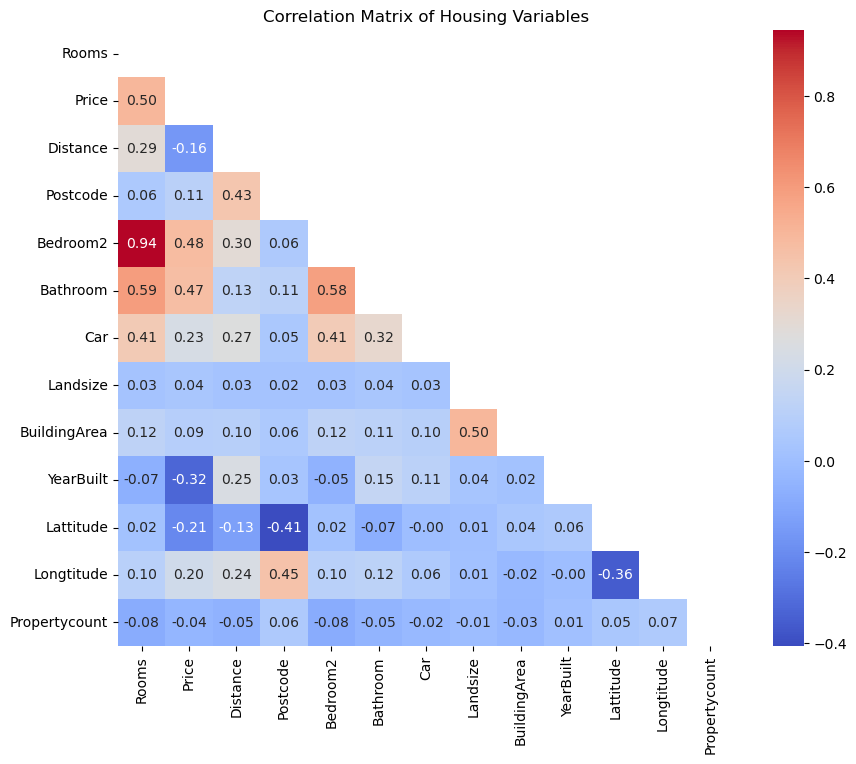

In [38]:
corr = df.corr(numeric_only=True)

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))

# Pass the mask into the heatmap function
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", square=True)

plt.title("Correlation Matrix of Housing Variables")

In [40]:
# ================================
# Prepare data for research questions
# ================================

# Keep the cleaned df, and create a new dataset for analysis
df_analysis = df.copy()

# Make property type names easier to understand
df_analysis['Type_Label'] = df_analysis['Type'].map({
    'h': 'House',
    'u': 'Unit',
    't': 'Townhouse'
})

# Create useful variables
df_analysis['Price_Million'] = df_analysis['Price'] / 1000000

# Property age: sale year - year built
df_analysis['SaleYear'] = df_analysis['Date'].dt.year
df_analysis['PropertyAge'] = df_analysis['SaleYear'] - df_analysis['YearBuilt']

# Remove impossible property age values
df_analysis.loc[df_analysis['PropertyAge'] < 0, 'PropertyAge'] = np.nan

# Price per room, useful for value-for-money analysis
df_analysis['Price_per_Room'] = df_analysis['Price'] / df_analysis['Rooms'].replace(0, np.nan)

# For clearer poster charts, remove extreme outliers only in plotting dataset
df_plot = df_analysis[
    (df_analysis['Price'] > 0) &
    (df_analysis['Rooms'] > 0) &
    (df_analysis['Distance'] >= 0) &
    (df_analysis['Price'] <= df_analysis['Price'].quantile(0.99)) &
    (df_analysis['Landsize'] <= df_analysis['Landsize'].quantile(0.99))
].copy()

print("Rows in original cleaned data:", len(df_analysis))
print("Rows used for poster charts:", len(df_plot))

Rows in original cleaned data: 13580
Rows used for poster charts: 13308


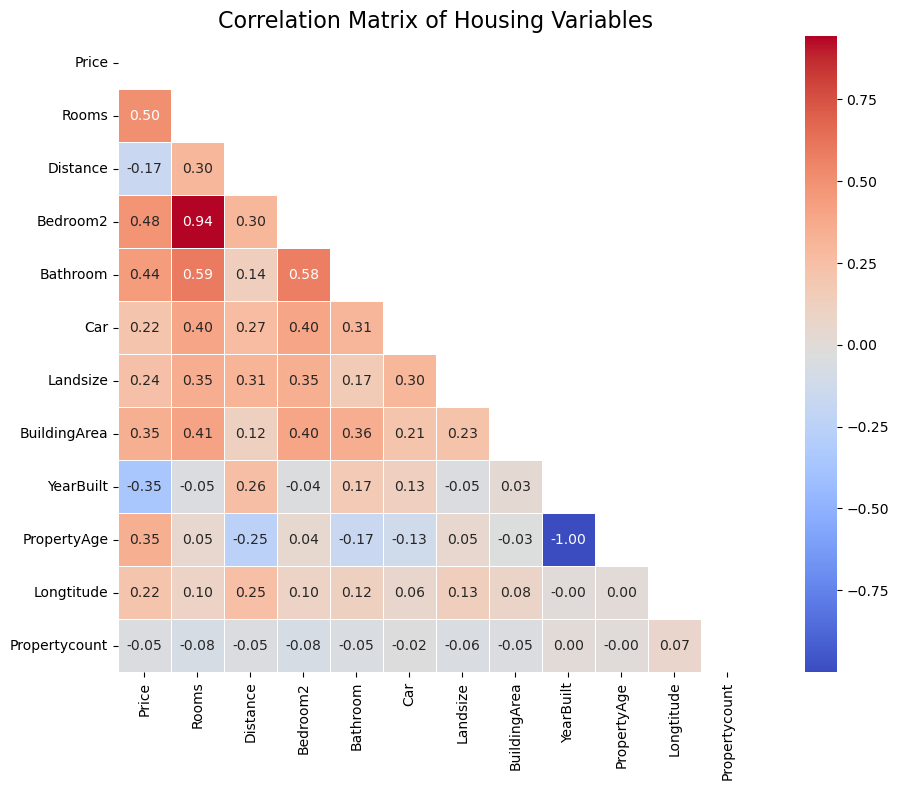

In [41]:
# ================================
# Q1: Factors influencing affordability
# Chart 1: Correlation heatmap
# ================================

numeric_cols = [
    'Price', 'Rooms', 'Distance', 'Bedroom2', 'Bathroom', 'Car',
    'Landsize', 'BuildingArea', 'YearBuilt', 'PropertyAge',
    'Latitude', 'Longtitude', 'Propertycount'
]

# Keep only columns that actually exist
numeric_cols = [col for col in numeric_cols if col in df_plot.columns]

corr = df_plot[numeric_cols].corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix of Housing Variables', fontsize=16)
plt.tight_layout()
plt.show()

The correlation matrix shows that housing price is most positively related to rooms, bedrooms, bathrooms and building area. Distance from the CBD has a negative relationship with price, suggesting that properties further from the CBD are generally cheaper, although the relationship is not very strong.

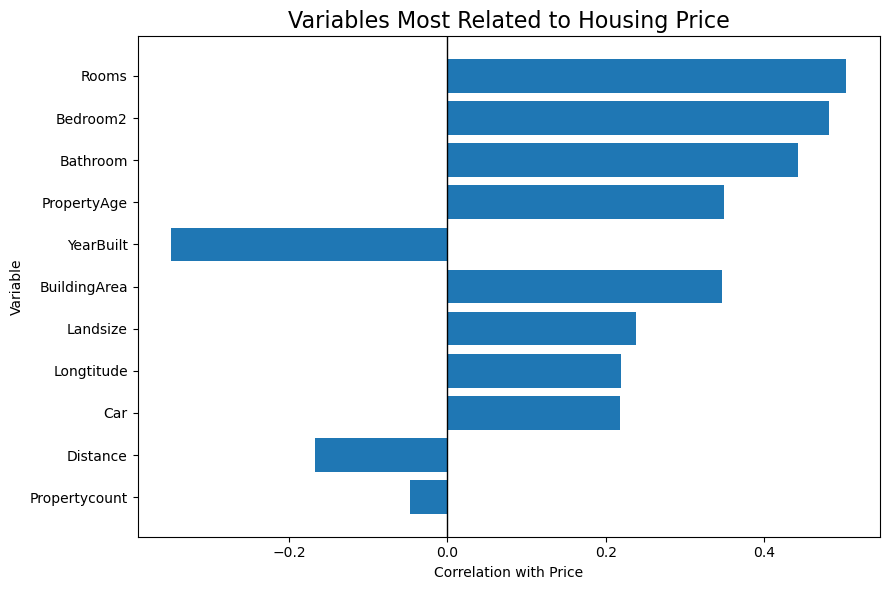

Correlation with Price:
Rooms            0.503899
Bedroom2         0.482126
Bathroom         0.442346
PropertyAge      0.349156
YearBuilt       -0.348971
BuildingArea     0.347476
Landsize         0.237683
Longtitude       0.218831
Car              0.218112
Distance        -0.167279
Propertycount   -0.047620
Name: Price, dtype: float64


In [42]:
# ================================
# Q1: Factors influencing affordability
# Chart 2: Variables most related to Price
# ================================

price_corr = corr['Price'].drop('Price').sort_values(
    key=lambda x: abs(x),
    ascending=True
)

plt.figure(figsize=(9, 6))
plt.barh(price_corr.index, price_corr.values)

plt.axvline(0, color='black', linewidth=1)
plt.title('Variables Most Related to Housing Price', fontsize=16)
plt.xlabel('Correlation with Price')
plt.ylabel('Variable')

plt.tight_layout()
plt.show()

print("Correlation with Price:")
print(price_corr.sort_values(key=lambda x: abs(x), ascending=False))

The strongest positive relationships with price are rooms, bedrooms and bathrooms, indicating that larger properties are generally more expensive. Distance from the CBD has a negative correlation with price, while property count has very limited influence.

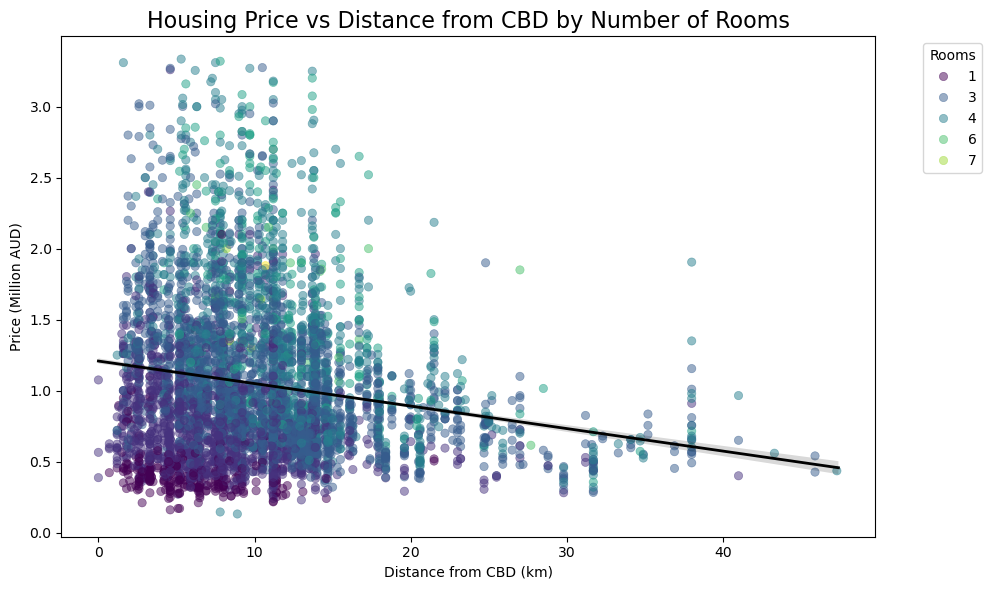

In [43]:
# ================================
# Q2: Price, rooms and distance from CBD
# Scatter plot
# ================================

# Sample data to avoid overly crowded scatter plot
sample_df = df_plot.sample(
    n=min(5000, len(df_plot)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x='Distance',
    y='Price_Million',
    hue='Rooms',
    palette='viridis',
    alpha=0.5,
    edgecolor=None
)

# Add trend line
sns.regplot(
    data=df_plot,
    x='Distance',
    y='Price_Million',
    scatter=False,
    color='black',
    line_kws={'linewidth': 2}
)

plt.title('Housing Price vs Distance from CBD by Number of Rooms', fontsize=16)
plt.xlabel('Distance from CBD (km)')
plt.ylabel('Price (Million AUD)')
plt.legend(title='Rooms', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

The scatter plot shows a general downward trend between distance from the CBD and housing price. Properties closer to the CBD tend to have higher prices, while prices become lower as distance increases. However, the spread of points also shows that rooms and other location factors still affect price.

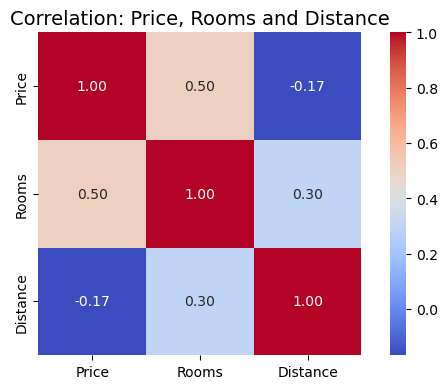

             Price     Rooms  Distance
Price     1.000000  0.503899 -0.167279
Rooms     0.503899  1.000000  0.299792
Distance -0.167279  0.299792  1.000000


In [44]:
# ================================
# Q2: Correlation between price, rooms and distance
# ================================

q2_corr = df_plot[['Price', 'Rooms', 'Distance']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(
    q2_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    square=True
)

plt.title('Correlation: Price, Rooms and Distance', fontsize=14)
plt.tight_layout()
plt.show()

print(q2_corr)

Price is moderately correlated with rooms, while its relationship with distance is weaker and negative. This suggests that affordability is not only about location; larger properties further from the CBD may offer more space at lower prices.

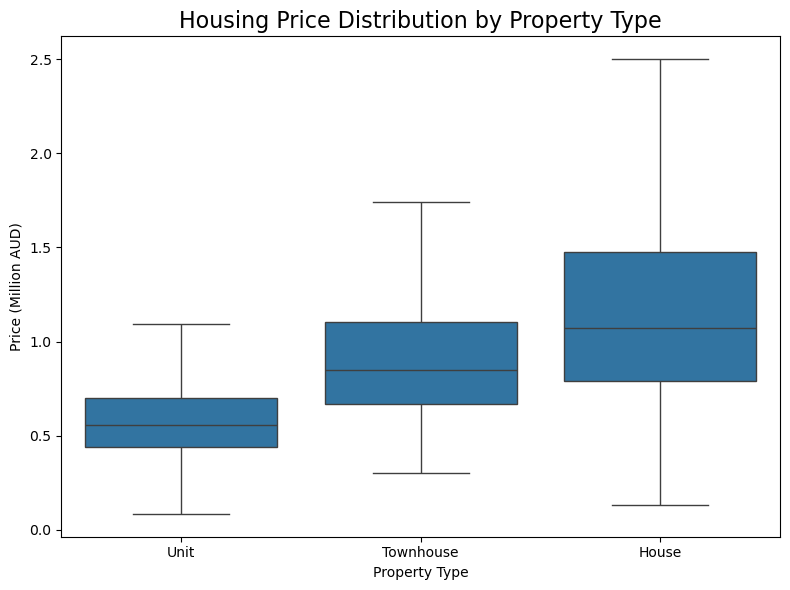

In [45]:
# ================================
# Q3: Best value property type
# Chart 1: Price distribution by property type
# ================================

type_order = ['Unit', 'Townhouse', 'House']

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_plot,
    x='Type_Label',
    y='Price_Million',
    order=type_order,
    showfliers=False
)

plt.title('Housing Price Distribution by Property Type', fontsize=16)
plt.xlabel('Property Type')
plt.ylabel('Price (Million AUD)')

plt.tight_layout()
plt.show()

Units have the lowest median price and a more compact price range, making them the most affordable option overall. Houses have the highest median price and the widest price spread, while townhouses sit between units and houses.

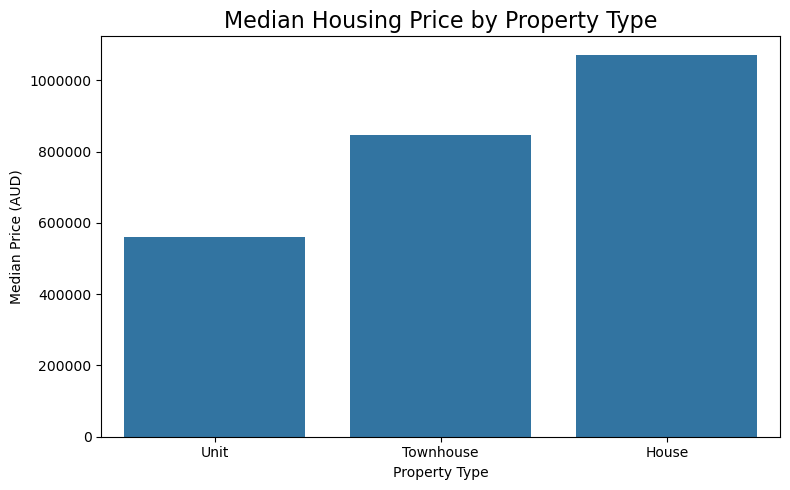

  Type_Label  Count  Median_Price  Median_Rooms  Median_Price_per_Room
0       Unit   2918      560000.0           2.0          300000.000000
1  Townhouse   1106      846750.0           3.0          306333.333333
2      House   9284     1070000.0           3.0          350000.000000


In [46]:
# ================================
# Q3: Best value property type
# Chart 2: Median price by property type
# ================================

type_summary = (
    df_plot
    .groupby('Type_Label')
    .agg(
        Count=('Price', 'size'),
        Median_Price=('Price', 'median'),
        Median_Rooms=('Rooms', 'median'),
        Median_Price_per_Room=('Price_per_Room', 'median')
    )
    .reindex(type_order)
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=type_summary,
    x='Type_Label',
    y='Median_Price',
    order=type_order
)

plt.title('Median Housing Price by Property Type', fontsize=16)
plt.xlabel('Property Type')
plt.ylabel('Median Price (AUD)')

plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

print(type_summary)

Units have the lowest median price at around $560,000, making them the most affordable option for young or first-home buyers. Houses have the highest median price at around $1.07 million, while townhouses provide a middle option.

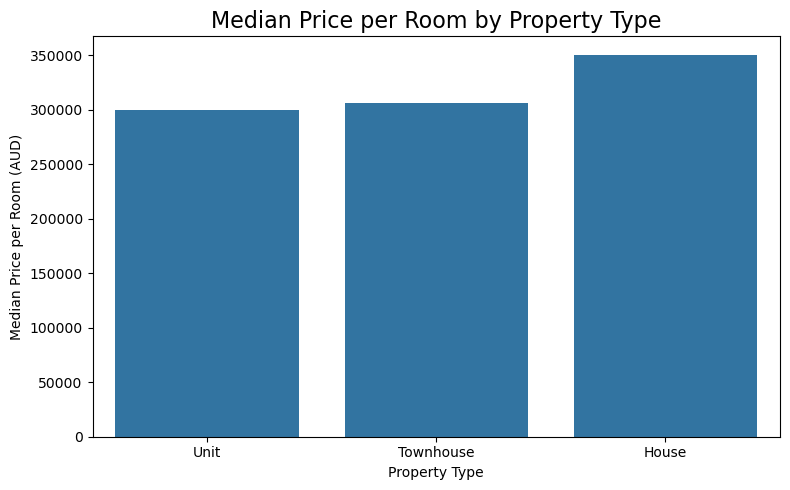

In [47]:
# ================================
# Q3: Value for money
# Chart 3: Median price per room by property type
# ================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=type_summary,
    x='Type_Label',
    y='Median_Price_per_Room',
    order=type_order
)

plt.title('Median Price per Room by Property Type', fontsize=16)
plt.xlabel('Property Type')
plt.ylabel('Median Price per Room (AUD)')

plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

When comparing median price per room, units still provide the lowest cost per room, while houses have the highest. This suggests that units may offer better value for money for first-home buyers with limited budgets.

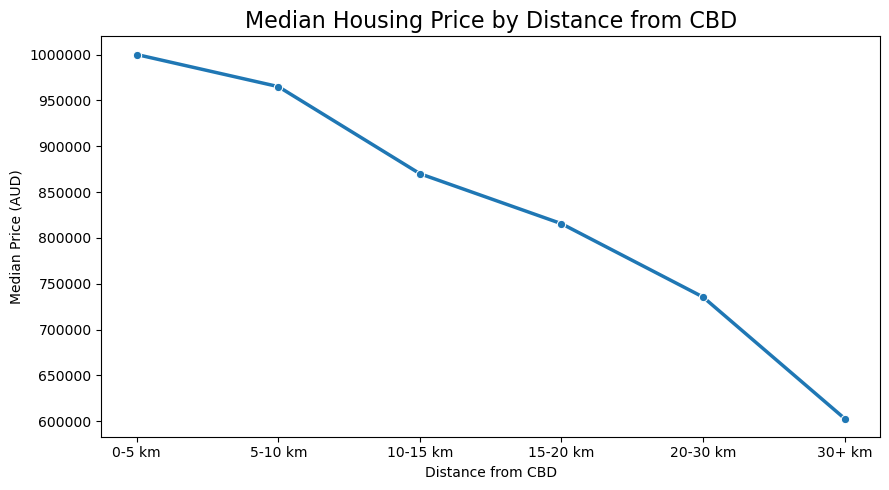

  Distance_Band  Median_Price  Average_Price  Count
0        0-5 km     1000000.0   1.094047e+06   2125
1       5-10 km      965000.0   1.116472e+06   4989
2      10-15 km      870000.0   1.022706e+06   4571
3      15-20 km      815500.0   9.195356e+05    903
4      20-30 km      735500.0   7.756601e+05    514
5        30+ km      603000.0   6.244124e+05    206


In [48]:
# ================================
# Q4: Does living further from CBD mean cheaper housing?
# Chart 1: Median price by distance band
# ================================

distance_bins = [0, 5, 10, 15, 20, 30, 50]
distance_labels = ['0-5 km', '5-10 km', '10-15 km', '15-20 km', '20-30 km', '30+ km']

df_plot['Distance_Band'] = pd.cut(
    df_plot['Distance'],
    bins=distance_bins,
    labels=distance_labels,
    include_lowest=True
)

distance_summary = (
    df_plot
    .dropna(subset=['Distance_Band'])
    .groupby('Distance_Band', observed=True)
    .agg(
        Median_Price=('Price', 'median'),
        Average_Price=('Price', 'mean'),
        Count=('Price', 'size')
    )
    .reset_index()
)

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=distance_summary,
    x='Distance_Band',
    y='Median_Price',
    marker='o',
    linewidth=2.5
)

plt.title('Median Housing Price by Distance from CBD', fontsize=16)
plt.xlabel('Distance from CBD')
plt.ylabel('Median Price (AUD)')

plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

print(distance_summary)

Median housing price decreases steadily as distance from the CBD increases. Properties within 0–5 km have a median price of around $1.0 million, while properties over 30 km from the CBD have a median price of around $603,000. This suggests that living further from the CBD generally improves affordability.

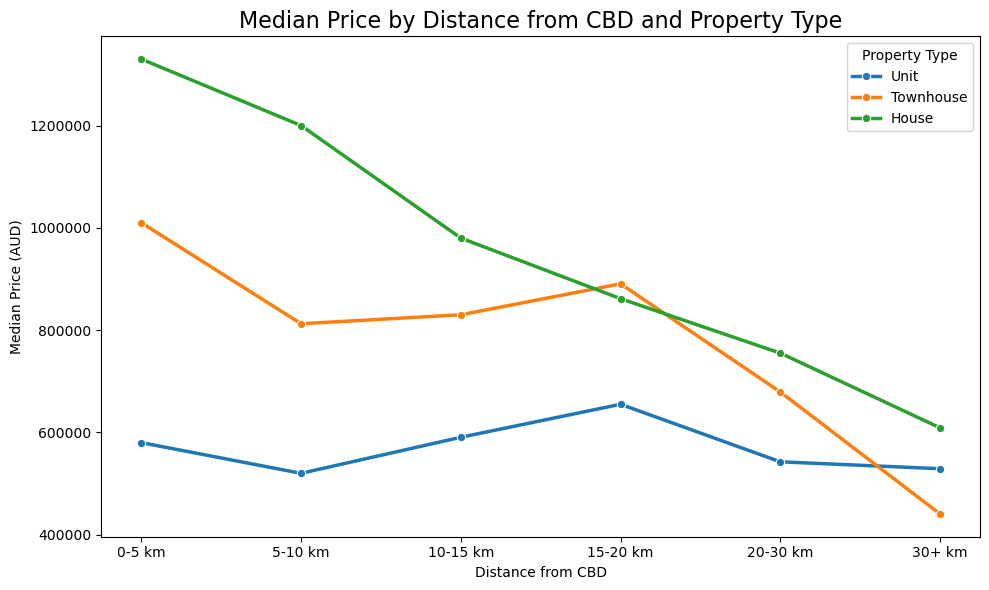

In [49]:
# ================================
# Q4: Distance from CBD by property type
# Chart 2: Median price by distance band and property type
# ================================

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_plot.dropna(subset=['Distance_Band', 'Type_Label']),
    x='Distance_Band',
    y='Price',
    hue='Type_Label',
    hue_order=type_order,
    estimator='median',
    errorbar=None,
    marker='o',
    linewidth=2.5
)

plt.title('Median Price by Distance from CBD and Property Type', fontsize=16)
plt.xlabel('Distance from CBD')
plt.ylabel('Median Price (AUD)')
plt.ticklabel_format(style='plain', axis='y')
plt.legend(title='Property Type')

plt.tight_layout()
plt.show()

Houses show the strongest price decline as distance from the CBD increases, while units remain the most affordable property type across most distance bands. This means distance improves affordability overall, but property type still plays an important role in determining housing value.